In [5]:
import os
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define Paths
# Double-check this matches the exact path in your Google Drive!
zip_path = '/content/drive/MyDrive/Colab Notebooks/AI535_Final_Project/ModelNet40.zip'
local_extract_path = '/content/data'
root_dir = os.path.join(local_extract_path, 'ModelNet40')

# 3. Extract if not already extracted in this session
if not os.path.exists(root_dir):
    print("Extracting ModelNet40 to local Colab storage. This may take a minute...")
    # -q for quiet, -d for destination directory
    !unzip -q "{zip_path}" -d {local_extract_path}
    print("Extraction complete!")
else:
    print("Data is already extracted and ready to go.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracting ModelNet40 to local Colab storage. This may take a minute...
Extraction complete!


## Setup W&B and configure GPU
*Initialize tracking and assign hardware.*

In [6]:
import torch
import wandb

wandb.login()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## ModelNet40 Dataset Loading and Preprocessing
*Parse `.off` files, sample exactly $N=1024$ points, apply zero-mean normalization, and prepare PyTorch DataLoaders.*

In [7]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

root_dir = '/content/data/ModelNet40'

# Dynamically map the 40 classes
classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}

def load_off(file_path, n_points=1024):
    with open(file_path, 'r') as f:
        lines = f.readlines()

    if lines[0].strip() == 'OFF':
        n_verts = int(lines[1].strip().split()[0])
        verts_start = 2
    else:
        n_verts = int(lines[0].strip()[3:].split()[0])
        verts_start = 1

    verts = np.array([ [float(x) for x in l.strip().split()] for l in lines[verts_start:verts_start + n_verts] ])

    if len(verts) >= n_points:
        indices = np.random.choice(len(verts), n_points, replace=False)
    else:
        indices = np.random.choice(len(verts), n_points, replace=True)
    verts = verts[indices]

    # Normalization
    verts = verts - np.mean(verts, axis=0)
    dist = np.max(np.sqrt(np.sum(verts**2, axis=1)))
    verts = verts / dist

    return torch.tensor(verts, dtype=torch.float32)

class FastModelNetDataset(Dataset):
    def __init__(self, root, split='train', n_points=1024):
        self.n_points = n_points
        self.files = []
        for cls_name, idx in class_to_idx.items():
            cls_folder = os.path.join(root, cls_name, split)
            if os.path.exists(cls_folder):
                for f in os.listdir(cls_folder):
                    if f.endswith('.off'):
                        self.files.append({'path': os.path.join(cls_folder, f), 'label': idx})

        # --- THE FIX: PRE-LOAD EVERYTHING INTO HIGH RAM ---
        print(f"Parsing and caching {len(self.files)} {split} files into RAM. This will take ~1-2 minutes...")
        self.data = []
        self.labels = []
        for item in self.files:
            points = load_off(item['path'], self.n_points)
            # Transpose here so we don't have to do it during training
            self.data.append(points.transpose(0, 1))
            self.labels.append(item['label'])
        print(f"Finished caching {split} split!")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        # Now, getting an item is an instant memory lookup!
        return self.data[idx], self.labels[idx]

batch_size = 128 # You can safely increase this to 128 on an A100!

trainset = FastModelNetDataset(root_dir, split='train')
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)

testset = FastModelNetDataset(root_dir, split='test')
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Data ready for instant access!")

Parsing and caching 9843 train files into RAM. This will take ~1-2 minutes...
Finished caching train split!
Parsing and caching 2468 test files into RAM. This will take ~1-2 minutes...
Finished caching test split!
Data ready for instant access!


## PointNet Architecture
*Create the baseline Spatial Deep Network using shared MLPs and a symmetric function (Global Max Pooling) to achieve permutation invariance.*

In [8]:
import torch.nn as nn
import torch.nn.functional as F

class PointNetBaseline(nn.Module):
    def __init__(self, num_classes=40):
        super(PointNetBaseline, self).__init__()

        # Shared MLPs
        self.conv1 = nn.Conv1d(3, 64, 1)
        self.conv2 = nn.Conv1d(64, 128, 1)
        self.conv3 = nn.Conv1d(128, 1024, 1)

        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(1024)

        # Classification Head
        self.fc1 = nn.Linear(1024, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, num_classes)

        self.bn4 = nn.BatchNorm1d(512)
        self.bn5 = nn.BatchNorm1d(256)
        self.dropout = nn.Dropout(p=0.3)

    def forward(self, x):
        # x is shape (Batch, 3, N)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))

        # Symmetric Function: Global Max Pooling
        x = torch.max(x, 2)[0]

        x = F.relu(self.bn4(self.fc1(x)))
        x = F.relu(self.bn5(self.fc2(self.dropout(x))))
        out = self.fc3(x)
        return out

model = PointNetBaseline().to(device)
print("PointNet initialized!")

PointNet initialized!


## Training Configuration and W&B Tracking
*Train the baseline model using AdamW (optimized for deeper spatial networks).*

In [17]:
import torch.optim as optim

EPOCHS = 150
LEARNING_RATE = 0.001
WEIGHT_DECAY = 0.0001

wandb.init(
    project="ai535-final-project",
    name="pointnet-baseline-150ep",
    config={
        "epochs": EPOCHS,
        "batch_size": batch_size,
        "learning_rate": LEARNING_RATE,
        "architecture": "PointNet",
        "dataset": "ModelNet40",
        "optimizer": "AdamW"
    }
)

criterion = nn.CrossEntropyLoss()
# AdamW is preferred for Point Clouds over SGD to prevent early plateau
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

wandb.watch(model, criterion, log="all", log_freq=10)
print("Loss, Optimizer, Scheduler, and W&B initialized!")

Loss, Optimizer, Scheduler, and W&B initialized!


## Baseline Training and Evaluation
*Execute the training loop, evaluating Test Error % dynamically.*

In [18]:
print("Start Training PointNet...")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for i, data in enumerate(trainloader, 0):
        inputs, labels = data[0].to(device), data[1].to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    avg_train_loss = running_loss / len(trainset)

    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for data in testloader:
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = model(inputs)

            loss = criterion(outputs, labels)
            test_loss += loss.item() * inputs.size(0)

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_test_loss = test_loss / len(testset)
    test_error = 100.0 * (1 - correct / total)

    wandb.log({
        "Epoch": epoch + 1,
        "Training Loss": avg_train_loss,
        "Testing Loss": avg_test_loss,
        "Testing Error (%)": test_error,
        "Learning Rate": current_lr
    })

    print(f"Epoch [{epoch+1}/{EPOCHS}] - Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f} | Test Error: {test_error:.2f}% | LR: {current_lr:.5f}")

print("Finished Training Baseline PointNet Model!")
wandb.finish()

Start Training PointNet...
Epoch [1/150] - Train Loss: 0.3396 | Test Loss: 0.9117 | Test Error: 27.92% | LR: 0.00100
Epoch [2/150] - Train Loss: 0.3019 | Test Loss: 0.9629 | Test Error: 26.46% | LR: 0.00100
Epoch [3/150] - Train Loss: 0.2779 | Test Loss: 0.8116 | Test Error: 22.85% | LR: 0.00100
Epoch [4/150] - Train Loss: 0.2819 | Test Loss: 0.9521 | Test Error: 26.66% | LR: 0.00100
Epoch [5/150] - Train Loss: 0.2698 | Test Loss: 0.8485 | Test Error: 24.39% | LR: 0.00100
Epoch [6/150] - Train Loss: 0.2426 | Test Loss: 0.9202 | Test Error: 26.09% | LR: 0.00100
Epoch [7/150] - Train Loss: 0.2323 | Test Loss: 0.7307 | Test Error: 20.14% | LR: 0.00099
Epoch [8/150] - Train Loss: 0.2152 | Test Loss: 0.9915 | Test Error: 27.80% | LR: 0.00099
Epoch [9/150] - Train Loss: 0.2075 | Test Loss: 0.9904 | Test Error: 25.12% | LR: 0.00099
Epoch [10/150] - Train Loss: 0.1903 | Test Loss: 0.9111 | Test Error: 24.19% | LR: 0.00099
Epoch [11/150] - Train Loss: 0.1855 | Test Loss: 0.8862 | Test Error: 24

Epoch,▁▁▂▂▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▇▇▇▇▇▇▇██
Learning Rate,███████▇▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▅▄▃▃▃▃▂▂▂▂▁▁▁▁▁▁
Testing Error (%),█▅▇▆▇▅▃▄▄▄▃▄▃▂▃▂▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
Testing Loss,▃▇▄▅▅▁▅▆▄▄▃▃▄▄▃▃▃▄▅▄▄▆▄▅▄▄▅▆▅▅█▅▆▅▆▆▆▇▇▆
Training Loss,█▅▄▄▄▄▄▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Epoch,150
Learning Rate,0
Testing Error (%),15.68071
Testing Loss,0.95235
Training Loss,0.00198


## Overall Accuracy (OA) and Mean Per-Class Accuracy (mAcc)

In [20]:
import torch

# --- THE PRO-TA FIX: Surgically remove lingering PyTorch hooks ---
for module in model.modules():
    module._forward_hooks.clear()
    module._backward_hooks.clear()
    module._forward_pre_hooks.clear()

# 1. Set the already-trained model to evaluation mode
model.eval()

# 2. Initialize tracking variables
total = 0
correct = 0
class_correct = torch.zeros(40).to(device)
class_total = torch.zeros(40).to(device)

print("Evaluating trained Baseline PointNet on the test set...")

# 3. Run the test set without tracking gradients
with torch.no_grad():
    for points, labels in testloader:
        points, labels = points.to(device), labels.to(device)

        # Forward pass
        outputs = model(points)
        _, predicted = torch.max(outputs.data, 1)

        # Overall Accuracy tracking
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # Mean Per-Class Accuracy tracking
        c = (predicted == labels)
        for i in range(labels.size(0)):
            label = labels[i]
            class_correct[label] += c[i].item()
            class_total[label] += 1

# 4. Calculate Final Metrics
# Overall Accuracy (OA)
oa = 100.0 * correct / total

# Mean Per-Class Accuracy (mAcc)
# We use torch.clamp to avoid division by zero if a class is somehow missing
per_class_acc = class_correct / torch.clamp(class_total, min=1)
macc = 100.0 * torch.mean(per_class_acc).item()

print("-" * 30)
print(f"Final Overall Accuracy (OA):       {oa:.2f}%")
print(f"Final Mean Per-Class Acc (mAcc):   {macc:.2f}%")
print("-" * 30)

# Optional: Print out the worst performing classes to discuss in your report
print("\nLowest performing classes:")
acc_dict = {classes[i]: (per_class_acc[i].item() * 100) for i in range(40)}
sorted_acc = sorted(acc_dict.items(), key=lambda x: x[1])
for cls_name, acc in sorted_acc[:5]:
    print(f"{cls_name:>15}: {acc:.2f}%")

Evaluating trained Baseline PointNet on the test set...
------------------------------
Final Overall Accuracy (OA):       84.32%
Final Mean Per-Class Acc (mAcc):   80.25%
------------------------------

Lowest performing classes:
     flower_pot: 10.00%
          radio: 50.00%
          stool: 55.00%
            cup: 60.00%
           lamp: 65.00%


## Images

Gathering predictions from the test set...


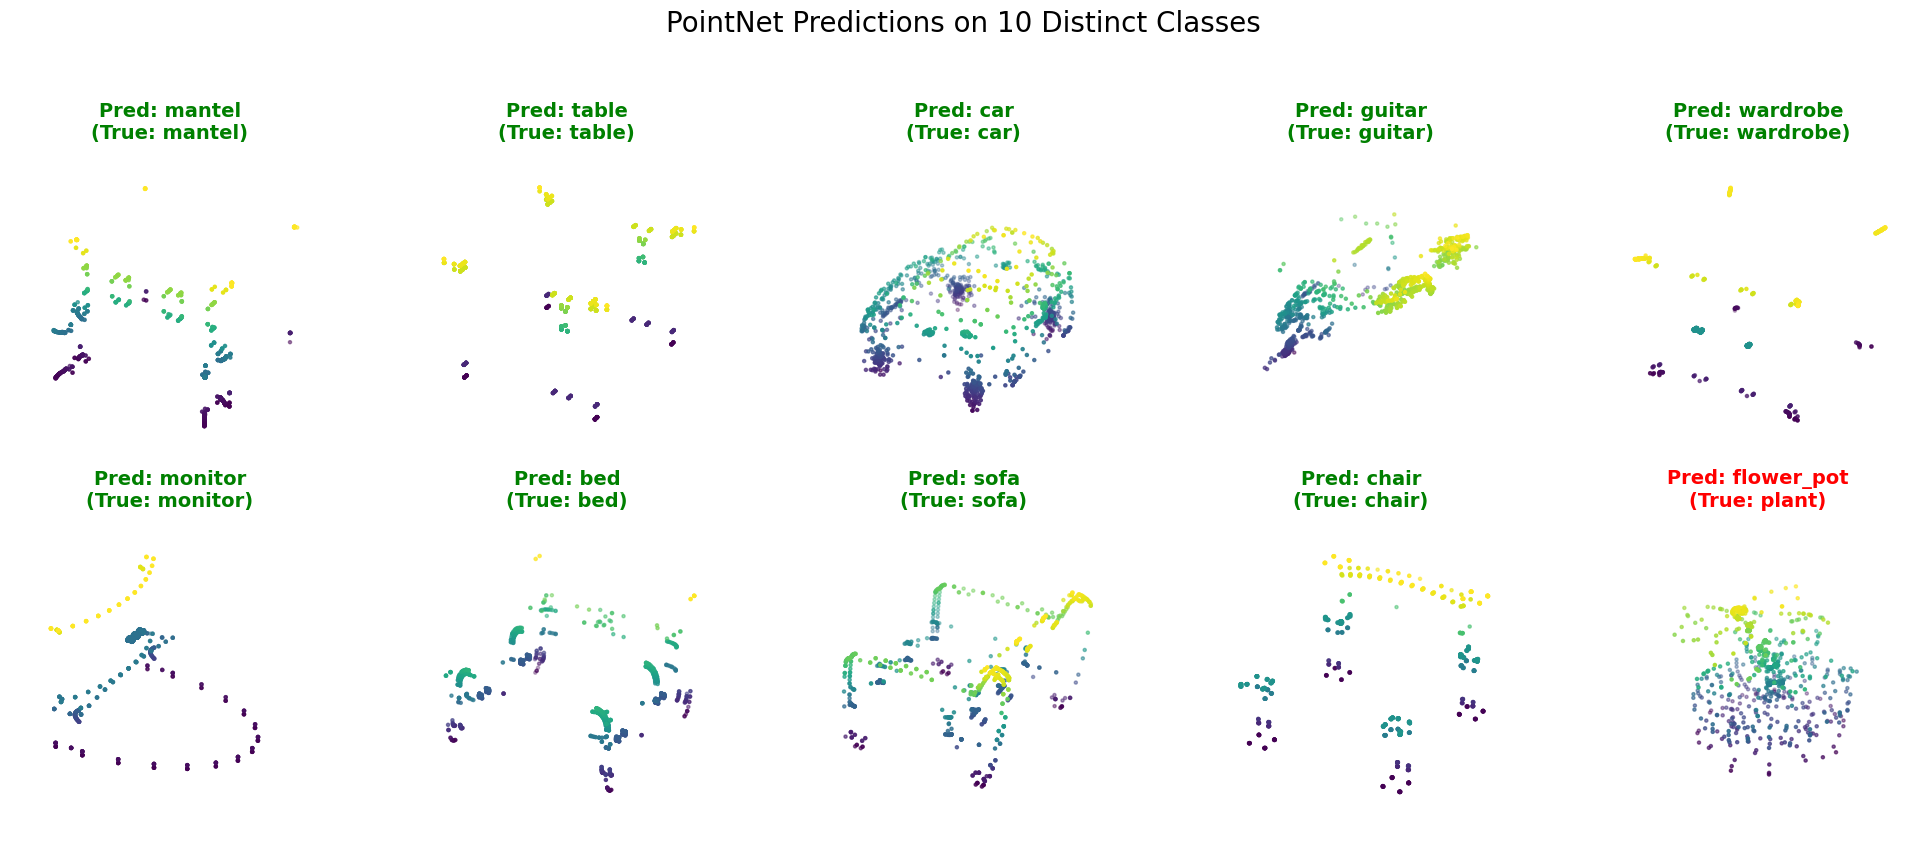

Visualization saved as '10_class_predictions.png'


In [21]:
import matplotlib.pyplot as plt
import torch
import numpy as np
import random

# --- THE PRO-TA FIX: Surgically remove PyTorch hooks, bypassing W&B ---
for module in model.modules():
    module._forward_hooks.clear()
    module._backward_hooks.clear()
    module._forward_pre_hooks.clear()

# 1. Set model to evaluation mode
model.eval()

all_candidates = []

# 2. Run the entire test set through the model to get predictions
print("Gathering predictions from the test set...")
with torch.no_grad():
    for points, labels in testloader:
        points_gpu = points.to(device)
        outputs = model(points_gpu)
        _, preds = torch.max(outputs, 1)

        # Store the point cloud, predicted class, and true class
        for i in range(points.size(0)):
            all_candidates.append({
                'pc': points[i].cpu().numpy(), # Shape: (3, N)
                'pred': preds[i].item(),
                'true': labels[i].item()
            })

# 3. Shuffle to ensure we get a random selection every time we run this cell
random.shuffle(all_candidates)

# 4. Filter for 10 DISTINCT predicted classes
selected_samples = []
seen_preds = set()

for cand in all_candidates:
    if cand['pred'] not in seen_preds:
        seen_preds.add(cand['pred'])
        selected_samples.append(cand)
    if len(selected_samples) == 10:
        break

# 5. Plot the 10 samples in a 2x5 grid
fig = plt.figure(figsize=(20, 8))
fig.suptitle("PointNet Predictions on 10 Distinct Classes", fontsize=20, y=1.05)

for i, sample in enumerate(selected_samples):
    ax = fig.add_subplot(2, 5, i+1, projection='3d')

    # Transpose from (3, N) to (N, 3) for plotting
    pc = sample['pc'].transpose(1, 0)

    # 3D Scatter plot
    ax.scatter(pc[:, 0], pc[:, 1], pc[:, 2], s=5, c=pc[:, 2], cmap='viridis')

    # Get string names
    pred_name = classes[sample['pred']]
    true_name = classes[sample['true']]

    # Title logic: Green if correct, Red if wrong
    title_color = 'green' if sample['pred'] == sample['true'] else 'red'
    ax.set_title(f"Pred: {pred_name}\n(True: {true_name})", color=title_color, fontsize=14, fontweight='bold')

    ax.axis('off')

plt.tight_layout()
plt.show()

# Optional: Save it for your CVPR report
fig.savefig("10_class_predictions.png", bbox_inches='tight', dpi=300)
print("Visualization saved as '10_class_predictions.png'")